# 03 Profile-Based Model

Bu notebook kullanıcı profil bilgisini kullanarak öneri üretir.

Kullanılan sinyaller:
- `skin_type`
- `skin_tone`
- ürün kategorisi

Amaç, özellikle cold-start kullanıcılar için açıklanabilir bir öneri mekanizması kurmaktır.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data_interim"

products_clean = pd.read_csv(DATA_INTERIM / "products_clean.csv")
product_profile = pd.read_csv(DATA_INTERIM / "product_profile.csv")
reviews_full = pd.read_csv(DATA_INTERIM / "reviews_full_features.csv")

products_clean["product_id"] = products_clean["product_id"].astype(str)
product_profile["product_id"] = product_profile["product_id"].astype(str)
reviews_full["product_id"] = reviews_full["product_id"].astype(str)

profile_df = product_profile.merge(products_clean, on="product_id", how="left")
print(profile_df.shape)


(2350, 55)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_55000/2607953089.py:15: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_full = pd.read_csv(DATA_INTERIM / "reviews_full_features.csv")


## User Profile Signal Exploration


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_55000/3107064799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skin_type_counts, x="skin_type", y="count", ax=axes[0], palette="crest")
/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_55000/3107064799.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skin_tone_counts.head(10), x="skin_tone", y="count", ax=axes[1], palette="flare")


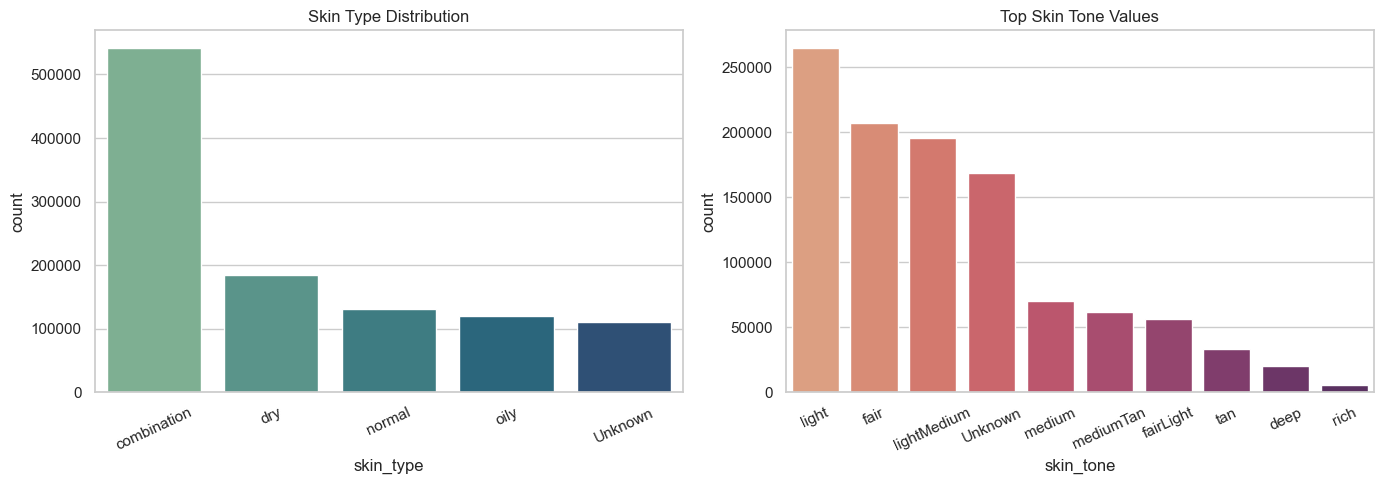

In [2]:
skin_type_counts = reviews_full["skin_type"].fillna("Unknown").value_counts().reset_index()
skin_type_counts.columns = ["skin_type", "count"]

skin_tone_counts = reviews_full["skin_tone"].fillna("Unknown").value_counts().reset_index()
skin_tone_counts.columns = ["skin_tone", "count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=skin_type_counts, x="skin_type", y="count", ax=axes[0], palette="crest")
axes[0].set_title("Skin Type Distribution")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=skin_tone_counts.head(10), x="skin_tone", y="count", ax=axes[1], palette="flare")
axes[1].set_title("Top Skin Tone Values")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()


## Grafik Yorumu

Skin type ve skin tone dağılımları kullanıcı profil bilgilerinin homojen dağılmadığını göstermektedir. Bu durum bazı profil kombinasyonlarında öneri üretmenin daha güçlü, bazılarında ise daha sınırlı olabileceğine işaret eder.


## Coverage Of Product Profile Scores


,column,coverage_ratio
0,combination_score,0.987234
9,light_tone_score,0.966383
7,fair_tone_score,0.960000
1,dry_score,0.957872
10,lightMedium_tone_score,0.936170
2,normal_score,0.932766
3,oily_score,0.900851
11,medium_tone_score,0.865106
12,mediumTan_tone_score,0.842128
8,fairLight_tone_score,0.827234


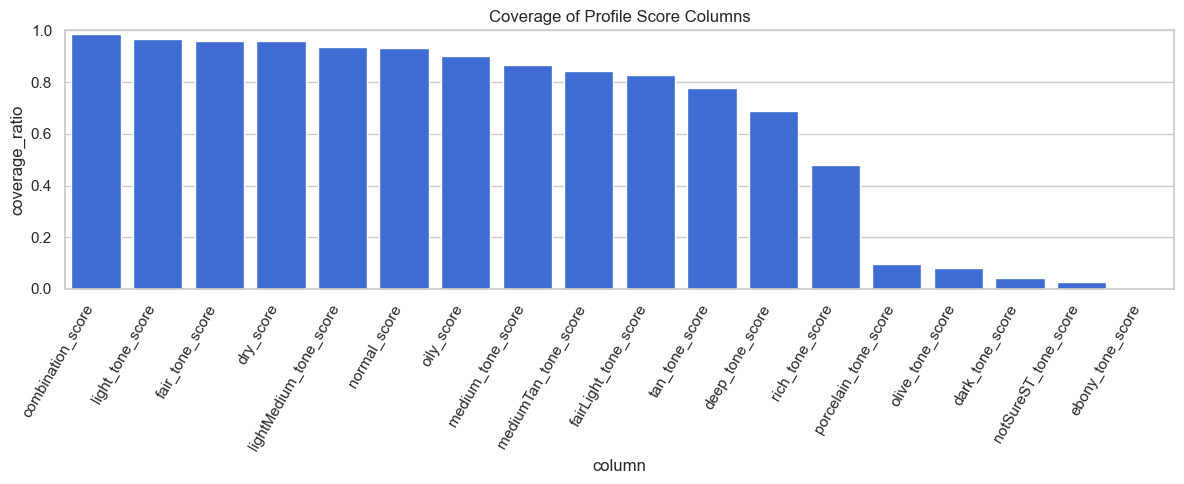

In [3]:
score_cols = [col for col in profile_df.columns if col.endswith("_score")]
coverage_df = pd.DataFrame({
    "column": score_cols,
    "coverage_ratio": [profile_df[col].notna().mean() for col in score_cols],
}).sort_values("coverage_ratio", ascending=False)

display(coverage_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=coverage_df, x="column", y="coverage_ratio", color="#2563EB")
plt.title("Coverage of Profile Score Columns")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1)
plt.tight_layout()


## Grafik Yorumu

Profile score coverage oranları, modelin hangi profil sütunlarında daha fazla gözleme dayandığını göstermektedir. Tezde bu kısım, profile-based modelin veri erişilebilirliğine bağlı güçlü ve zayıf yönlerini tartışmak için kullanılabilir.


## Recommendation Function

Ağırlık mantığı:
- skin type sinyali daha güçlü başlangıç sinyali kabul edilir
- ancak review sayısı arttıkça güven artar
- eksik sinyal varsa ağırlık yeniden normalize edilir


In [4]:
def recommend_profile_based(skin_type, skin_tone, category, top_n=10):
    df = profile_df.copy()
    df = df[
        df["tertiary_category"].fillna("").str.lower().str.contains(str(category).lower(), na=False)
    ].copy()

    if df.empty:
        fallback_df = products_clean[
            products_clean["tertiary_category"].fillna("").str.lower().str.contains(str(category).lower(), na=False)
        ].copy()
        if fallback_df.empty:
            return None
        fallback_df["rating"] = fallback_df["rating"].fillna(0)
        fallback_df["reviews"] = fallback_df["reviews"].fillna(0)
        fallback_df["loves_count"] = fallback_df["loves_count"].fillna(0)
        fallback_df["fallback_score"] = (
            0.5 * fallback_df["rating"]
            + 0.3 * np.log1p(fallback_df["reviews"])
            + 0.2 * np.log1p(fallback_df["loves_count"])
        )
        return fallback_df.sort_values("fallback_score", ascending=False).head(top_n)

    type_score_col = f"{str(skin_type).lower()}_score"
    type_count_col = f"{str(skin_type).lower()}_count"
    tone_score_col = f"{skin_tone}_tone_score"
    tone_count_col = f"{skin_tone}_tone_count"

    df["type_score"] = df[type_score_col] if type_score_col in df.columns else np.nan
    df["type_count"] = df[type_count_col] if type_count_col in df.columns else 0
    df["tone_score"] = df[tone_score_col] if tone_score_col in df.columns else np.nan
    df["tone_count"] = df[tone_count_col] if tone_count_col in df.columns else 0

    type_strength = np.sqrt(pd.Series(df["type_count"]).fillna(0))
    tone_strength = np.sqrt(pd.Series(df["tone_count"]).fillna(0))

    weighted_type = 0.7 * type_strength
    weighted_tone = 0.3 * tone_strength
    total_weight = (weighted_type + weighted_tone).replace(0, 1)

    df["dynamic_type_weight"] = weighted_type / total_weight
    df["dynamic_tone_weight"] = weighted_tone / total_weight

    df.loc[df["type_score"].isna(), "dynamic_type_weight"] = 0
    df.loc[df["tone_score"].isna(), "dynamic_tone_weight"] = 0

    normalized_sum = (df["dynamic_type_weight"] + df["dynamic_tone_weight"]).replace(0, 1)
    df["dynamic_type_weight"] = df["dynamic_type_weight"] / normalized_sum
    df["dynamic_tone_weight"] = df["dynamic_tone_weight"] / normalized_sum

    df["profile_score"] = (
        df["dynamic_type_weight"] * df["type_score"].fillna(0)
        + df["dynamic_tone_weight"] * df["tone_score"].fillna(0)
    )

    return df.sort_values("profile_score", ascending=False).head(top_n)


## Example Recommendation Cases


In [5]:
example_recs = recommend_profile_based(
    skin_type="dry",
    skin_tone="light",
    category="concealer",
    top_n=10,
)

display(example_recs[[col for col in [
    "product_name", "brand_name", "tertiary_category", "type_score", "tone_score", "profile_score", "fallback_score"
] if col in example_recs.columns]])


,product_name,brand_name,tertiary_category,fallback_score
5249,Radiant Creamy Concealer,NARS,Concealer,7.784894
7844,Born This Way Super Coverage Multi-Use Longwea...,Too Faced,Concealer,7.299616
5253,Soft Matte Complete Concealer,NARS,Concealer,7.187925
8431,Touche Éclat All-Over Brightening Concealer Pen,Yves Saint Laurent,Concealer,7.115465
3334,#FauxFilter Luminous Matte Buildable Coverage ...,HUDA BEAUTY,Concealer,7.100248
4710,Full Cover Concealer,MAKE UP FOR EVER,Concealer,7.066210
4224,Revealer Super Creamy + Brightening Concealer ...,Kosas,Concealer,7.018515
4357,Teint Idole Ultra Wear All Over Full Coverage ...,Lancôme,Concealer,6.990111
545,Boi-ing Cakeless Full Coverage Waterproof Liqu...,Benefit Cosmetics,Concealer,6.964664
646,Under Eye Corrector,Bobbi Brown,Concealer,6.910683


In [6]:
if example_recs is not None and "profile_score" in example_recs.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=example_recs, x="profile_score", y="product_name", color="#059669")
    plt.title("Example Profile-Based Recommendations")
    plt.xlabel("Profile Score")
    plt.ylabel("Product")
    plt.tight_layout()


## Sonuç Yorumu

Örnek öneri listesi, profile-based yaklaşımın kullanıcı cilt tipi ve ten tonu sinyallerini birleştirerek kategori odaklı ürün sıralaması üretebildiğini göstermektedir. Eğer `fallback_score` kullanılmışsa bu, ilgili kategoride yeterli profil sinyali bulunmadığı anlamına gelir ve tezde açıkça belirtilmelidir.


## Thesis Notes

Bu modelin tezde vurgulanabilecek yönleri:
- açıklanabilirlik yüksektir
- cold-start durumuna uygundur
- kullanıcı profili eksik veya dengesizse performans sınırlı kalabilir
